# Capstone project - Air passengers, start to finish

The course pipeline, on this series: explore it, decompose it, set the
benchmark floor, check what the floor leaves on the table, fit a model
through the framework, cross-validate, and read the result against the
floor.

**What is graded is the process, not the number.** A low MASE from one
holdout with no intervals scores worse than an honest analysis that
concludes the benchmark wins.

Full rules and report requirements: `brief.md`. Grading: `rubric.md`. This
notebook is the first deliverable; it should run top to bottom in under ten
minutes on Colab.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/SDAIAAcademy/international-airpassengers-project.git /content/proj
    %cd /content/proj
    !pip install -q -e .

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coursekit import plotting as P
from coursekit import scoring

P.use_course_style()

SEASON_LENGTH = 12
H = 12            # forecast horizon for cross-validation
H_REPORT = 24     # forecast horizon for the report

/content/proj
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.3 MB/s eta 0:00:00
  Building editable for international-airpassengers-project (pyproject.toml) ... done


/content/proj/coursekit/plotting.py:599: SyntaxWarning: invalid escape sequence '\h'
  :math:`\hat{F}` whose characteristics do not change over time -- so that a
/content/proj/coursekit/plotting.py:676: SyntaxWarning: invalid escape sequence '\h'
  """Draw the h-step errors :math:`e_{t+h|t} = y_{t+h} - \hat{y}_{t+h|t}`.


---
# 0. The data

Monthly international air passenger numbers, 1949-01 to 1960-12: 144
observations, no gaps. The Box & Jenkins classic (1970) — twelve years of
growth, and a year that does not repeat the same way twice.

Fetched from statsmodels' R-datasets on first run; no download step.

In [2]:
from statsmodels.datasets import get_rdataset

raw = get_rdataset("AirPassengers").data
t = raw["time"].astype(float).to_numpy()
years = np.floor(t).astype(int)
months = np.clip(np.round((t - years) * 12).astype(int) + 1, 1, 12)
df = pd.DataFrame({
    "unique_id": "Air passengers (Box & Jenkins)",
    "ds": pd.to_datetime(pd.Series(years).astype(str) + "-" +
                         pd.Series(months).astype(str).str.zfill(2) + "-01"),
    "y": raw["value"].astype(float),
}).sort_values("ds").reset_index(drop=True)
df.head()

,unique_id,ds,y
0,Air passengers (Box & Jenkins),1949-01-01,112.0
1,Air passengers (Box & Jenkins),1949-02-01,118.0
2,Air passengers (Box & Jenkins),1949-03-01,132.0
3,Air passengers (Box & Jenkins),1949-04-01,129.0
4,Air passengers (Box & Jenkins),1949-05-01,121.0


In [3]:
# Calendar checks: count, range, and monthly gaps.
n_obs = len(df)
range_ = (df["ds"].min(), df["ds"].max())
expected = pd.date_range(range_[0], range_[1], freq="MS")
n_gaps = len(expected.difference(df["ds"]))
print(f"{n_obs} months, {range_[0].date()} to {range_[1].date()}, {n_gaps} gaps")


144 months, 1949-01-01 to 1960-12-01, 0 gaps


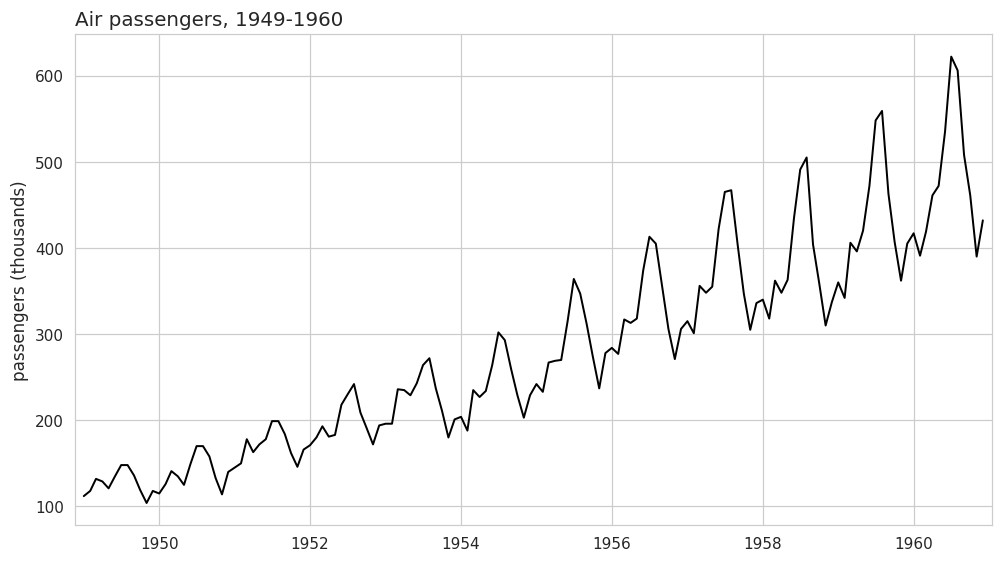

In [4]:
P.plot_series(df, title="Air passengers, 1949-1960",
              ylabel="passengers (thousands)", xlabel="")
plt.show()

**First read.** Passenger demand rises strongly from about 112 thousand in 1949 to 432 thousand in 1960, so the series has a clear upward trend. There is also a repeating yearly pattern, with large summer peaks and winter troughs; the seasonal swings get larger as the overall level grows, suggesting multiplicative seasonality.\n

---
# 1. Exploration and shape

The Day 1 toolkit, in order. Every chart should carry its claim: a title that
says what it shows, not just "series".

**1.1 Decompose.** STL, additive, period 12. Read all three panels: which
component does the work, and what does the remainder look like?

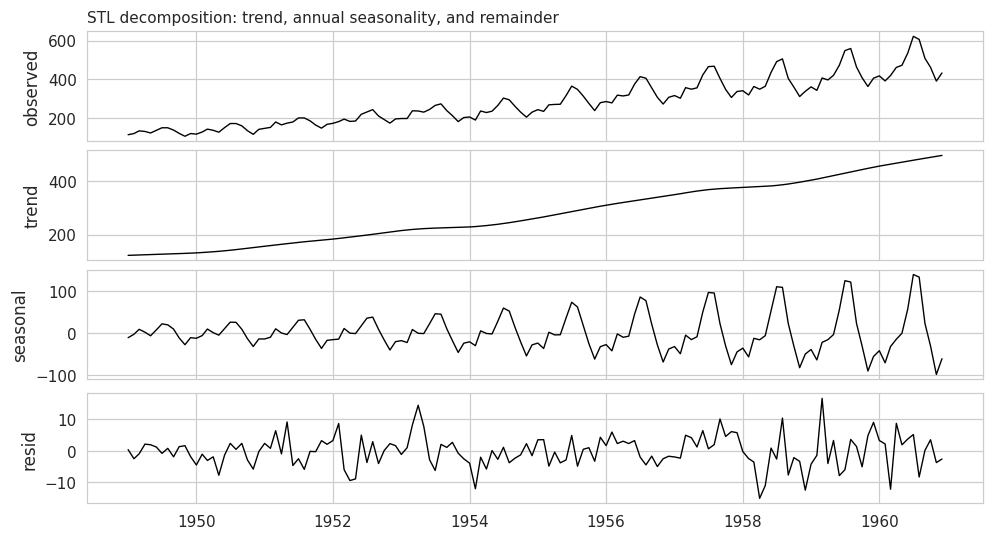

In [7]:
from statsmodels.tsa.seasonal import STL
import pandas as pd

series = df.set_index("ds")["y"]
dcmp = STL(series, period=SEASON_LENGTH, robust=False).fit()

# Create a DataFrame from the decomposition results
decomposition_df = pd.DataFrame({
    "observed": dcmp.observed,
    "trend": dcmp.trend,
    "seasonal": dcmp.seasonal,
    "resid": dcmp.resid
}).reset_index() # Reset index to make 'ds' a column

P.decomposition_plot(
    decomposition_df,
    cols=["observed", "trend", "seasonal", "resid"],
    title="STL decomposition: trend, annual seasonality, and remainder",
    x="ds",
)
plt.show()

**1.2 Trend and seasonal strength.** The two numbers from Day 1, computed
the same way (textbook formulas on the STL components). State what they
imply for model choice.

In [8]:
# Textbook strength measures from the STL components.
trend = dcmp.trend.to_numpy()
seasonal = dcmp.seasonal.to_numpy()
remainder = dcmp.resid.to_numpy()

trend_strength = max(0.0, 1.0 - np.var(remainder) / np.var(trend + remainder))
seasonal_strength = max(0.0, 1.0 - np.var(remainder) / np.var(seasonal + remainder))

print(f"trend strength: {trend_strength:.2f}")
print(f"seasonal strength: {seasonal_strength:.2f}")
print(
    "Both strengths are high, so the model needs to handle a strong trend and a strong "
    "12-month seasonal pattern; the growing seasonal amplitude also favors a multiplicative-style model."
)


trend strength: 1.00
seasonal strength: 0.99
Both strengths are high, so the model needs to handle a strong trend and a strong 12-month seasonal pattern; the growing seasonal amplitude also favors a multiplicative-style model.


**1.3 Autocorrelation.** The ACF of the raw series. What is at lag 12?
At 24? What does that tell you before you fit anything?

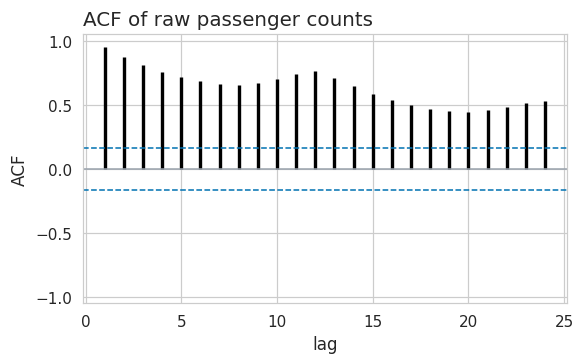

The large spike at lag 12 means observations one year apart are strongly related, confirming annual seasonality; the spike at lag 24 shows that this dependence persists across two years.


In [10]:
P.acf_plot(df["y"], nlags=24, title="ACF of raw passenger counts")
plt.show()
print(
    "The large spike at lag 12 means observations one year apart are strongly related, "
    "confirming annual seasonality; the spike at lag 24 shows that this dependence persists across two years."
)

---
# 2. The floor

The seasonal naive is the first model you fit on any series - not as a
formality, as the thing everything else has to beat. Fit it, check what it
leaves on the table, and give it an honest interval.

In [11]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

floor_sf = StatsForecast(models=[SeasonalNaive(season_length=SEASON_LENGTH)],
                         freq="MS", n_jobs=1)
floor_fc = floor_sf.forecast(df=df, h=H_REPORT, level=scoring.LEVELS)
floor_fc.head()

,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,417.0,407.799511,397.956005,386.435898,370.4595,345.822448,426.200489,436.043995,447.564102,463.5405,488.177552
1,Air passengers (Box & Jenkins),1961-02-01,391.0,381.799511,371.956005,360.435898,344.4595,319.822448,400.200489,410.043995,421.564102,437.5405,462.177552
2,Air passengers (Box & Jenkins),1961-03-01,419.0,409.799511,399.956005,388.435898,372.4595,347.822448,428.200489,438.043995,449.564102,465.5405,490.177552
3,Air passengers (Box & Jenkins),1961-04-01,461.0,451.799511,441.956005,430.435898,414.4595,389.822448,470.200489,480.043995,491.564102,507.5405,532.177552
4,Air passengers (Box & Jenkins),1961-05-01,472.0,462.799511,452.956005,441.435898,425.4595,400.822448,481.200489,491.043995,502.564102,518.5405,543.177552


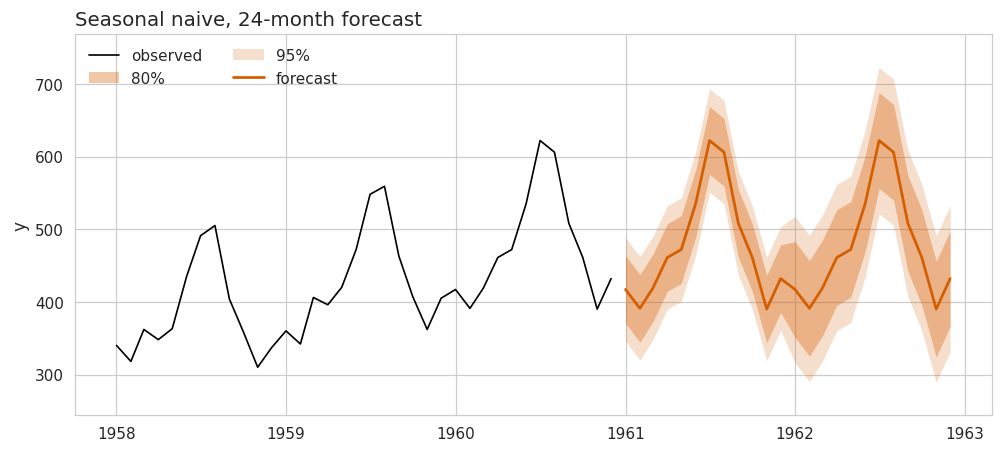

In [12]:
P.fan_chart(df, floor_fc.rename(columns={
            "SeasonalNaive": "mean",
            "SeasonalNaive-lo-20": "lo-20",
            "SeasonalNaive-lo-40": "lo-40",
            "SeasonalNaive-lo-60": "lo-60",
            "SeasonalNaive-lo-80": "lo-80",
            "SeasonalNaive-lo-95": "lo-95",
            "SeasonalNaive-hi-20": "hi-20",
            "SeasonalNaive-hi-40": "hi-40",
            "SeasonalNaive-hi-60": "hi-60",
            "SeasonalNaive-hi-80": "hi-80",
            "SeasonalNaive-hi-95": "hi-95",
            "ds": "ds"}),
            title="Seasonal naive, 24-month forecast",
            history_tail=36, levels=(80, 95))
plt.show()

**2.1 What is left on the table.** The floor's in-sample residuals are
``y_t - y_{t-12}`` over the series. Ljung-Box at 12 and 24 lags. If it is not
white noise, what structure is it, and which kind of model eats that
structure?

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Seasonal-naive in-sample residuals: y_t - y_{t-12}.
resid_floor = df["y"].to_numpy()[SEASON_LENGTH:] - df["y"].to_numpy()[:-SEASON_LENGTH]
lb_floor = acorr_ljungbox(resid_floor, lags=[12, 24], return_df=True)
print(lb_floor)
print(
    "The very small p-values reject white noise: after repeating last year's values, "
    "systematic structure remains. A model that can learn trend and seasonal dynamics, "
    "such as ETS/ARIMA/Theta, can try to absorb that remaining structure."
)

       lb_stat     lb_pvalue
12  234.493675  2.319678e-43
24  275.036389  1.711303e-44
The very small p-values reject white noise: after repeating last year's values, systematic structure remains. A model that can learn trend and seasonal dynamics, such as ETS/ARIMA/Theta, can try to absorb that remaining structure.


---
# 3. Your model: the framework

AutoGluon fits a zoo of models behind one call - every model in the zoo
below is a model you have met in this course. The install is large, so this
runs on Colab.

> Every cell in this section is **skip-guarded**: without `autogluon`
> installed it prints why and moves on, so the rest of the notebook still
> runs.

In [15]:
import importlib.util

HAS_AG = importlib.util.find_spec("autogluon") is not None
if not HAS_AG:
    print("autogluon is not installed. On Colab, run this and re-run the cell:")
    print("    !pip install -q 'autogluon.timeseries'")
    print("\n(Takes a few minutes. A runtime reset wipes it.)")
else:
    print("autogluon is available")

autogluon is not installed. On Colab, run this and re-run the cell:
    !pip install -q 'autogluon.timeseries'

(Takes a few minutes. A runtime reset wipes it.)


**3.1 The data conversion stays visible.** AutoGluon has its own
frame, its own column names, its own fit loop and its own leaderboard.
Writing it out by hand once is the point - the gap between two APIs doing
the same job is the thing to notice.

| | this course | AutoGluon |
|---|---|---|
| id column | `unique_id` | `item_id` |
| time column | `ds` | `timestamp` |
| value column | `y` | `target` (nameable) |
| frame | `pd.DataFrame` | `TimeSeriesDataFrame` |

In [16]:
if HAS_AG:
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

    # Long format to AutoGluon's long format: the same three columns, renamed.
    ag_long = df.rename(columns={"unique_id": "item_id", "ds": "timestamp"})
    tsdf = TimeSeriesDataFrame.from_data_frame(
        ag_long, id_column="item_id", timestamp_column="timestamp")

    # One 12-month holdout, cut the way AutoGluon expects.
    ag_train = tsdf.slice_by_timestep(None, -12)

    print(tsdf.head(3))
    print(f"\nfull: {len(tsdf)} rows   train: {len(ag_train)} rows")

In [17]:
if HAS_AG:
    # Local models only - the same zoo this course taught, nothing neural.
    ZOO = {"Naive": {}, "SeasonalNaive": {}, "AutoETS": {},
           "AutoARIMA": {}, "Theta": {}}

    predictor = TimeSeriesPredictor(
        prediction_length=12, target="y", eval_metric="MASE",
        freq="MS", verbosity=1)
    predictor.fit(ag_train, hyperparameters=ZOO, time_limit=120)

In [18]:
if HAS_AG:
    leaderboard = predictor.leaderboard(tsdf, silent=True)
    display(leaderboard)

    best_name = leaderboard.iloc[0]["model"]
    best_score = leaderboard.iloc[0]["score_val"]
    n_models = len(leaderboard)
    print(f"Best model: {best_name}")
    print(f"score_val sign: {'negative' if best_score < 0 else 'positive'}")
    print(f"Models/windows scored: {n_models} models on AutoGluon's single validation window.")
    print(
        "This ranking is useful as a shortlist, but it should not be treated as robust evidence "
        "because the framework leaderboard uses one internal holdout rather than the required eight rolling origins."
    )
else:
    print("AutoGluon was not installed; run the install cell on Colab and rerun this section.")


AutoGluon was not installed; run the install cell on Colab and rerun this section.


**3.2 Read what it handed back.** What is the *sign* of `score_val`, and
what does the answer to "how many windows" mean for how much you should
trust this ranking? It decides what the next section does with this table.
And: does the shortlist agree with the shape you read in section 1?

---
# 4. The harness

The framework's ranking came from one internal split. One holdout is not a
ranking. So the shortlist goes through the rolling-origin harness: eight
origins, twelve months each, the whole distribution scored - and the floor
stays in the table.

In [19]:
sf_cv = StatsForecast(
    models=[SeasonalNaive(season_length=SEASON_LENGTH)],
    freq="MS", n_jobs=1)
cv = sf_cv.cross_validation(df=df, h=H, step_size=H, n_windows=8,
                            level=scoring.LEVELS)
cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1953-01-01,1952-12-01,196.0,171.0,164.48674,157.518271,149.362895,138.052796,120.6116,177.51326,184.481729,192.637105,203.947204,221.3884
1,Air passengers (Box & Jenkins),1953-02-01,1952-12-01,196.0,180.0,173.48674,166.518271,158.362895,147.052796,129.6116,186.51326,193.481729,201.637105,212.947204,230.3884
2,Air passengers (Box & Jenkins),1953-03-01,1952-12-01,236.0,193.0,186.48674,179.518271,171.362895,160.052796,142.6116,199.51326,206.481729,214.637105,225.947204,243.3884
3,Air passengers (Box & Jenkins),1953-04-01,1952-12-01,235.0,181.0,174.48674,167.518271,159.362895,148.052796,130.6116,187.51326,194.481729,202.637105,213.947204,231.3884
4,Air passengers (Box & Jenkins),1953-05-01,1952-12-01,229.0,183.0,176.48674,169.518271,161.362895,150.052796,132.6116,189.51326,196.481729,204.637105,215.947204,233.3884


In [21]:
from statsforecast.models import AutoETS, AutoARIMA, AutoTheta, Naive, SeasonalNaive
from scipy.stats import norm

# Use the framework winner as the shortlist, then validate it through the course harness.
# AutoGluon's local-model name maps directly to the StatsForecast twin used below.
if HAS_AG:
    name_to_model = {
        "AutoETS": (AutoETS(season_length=SEASON_LENGTH), "AutoETS"),
        "AutoARIMA": (AutoARIMA(season_length=SEASON_LENGTH), "AutoARIMA"),
        "AutoTheta": (AutoTheta(season_length=SEASON_LENGTH), "AutoTheta"),
        "Theta": (AutoTheta(season_length=SEASON_LENGTH), "AutoTheta"),
        "SeasonalNaive": (SeasonalNaive(season_length=SEASON_LENGTH), "SeasonalNaive"),
        "Naive": (Naive(), "Naive"),
    }
    if best_name not in name_to_model:
        raise ValueError(f"Unsupported AutoGluon winner for this harness: {best_name}")
    MY_MODEL, MY_NAME = name_to_model[best_name]
else:
    # Safe fallback for environments where AutoGluon cannot be installed.
    MY_MODEL, MY_NAME = AutoETS(season_length=SEASON_LENGTH), "AutoETS"
    best_name = "AutoETS"

mysf = StatsForecast(models=[MY_MODEL], freq="MS", n_jobs=1)
mycv = mysf.cross_validation(
    df=df, h=H, step_size=H, n_windows=8, level=scoring.LEVELS
)

def fold_scales(frame):
    rows = []
    for cutoff, g in frame.groupby("cutoff"):
        train = df.loc[df["ds"] <= cutoff, "y"].to_numpy()
        d = train[SEASON_LENGTH:] - train[:-SEASON_LENGTH]
        rows.append({
            "cutoff": cutoff,
            "mase_scale": np.mean(np.abs(d)),
            "rmsse_scale": np.sqrt(np.mean(d ** 2)),
        })
    return pd.DataFrame(rows)

def normal_crps(y_true, mu, sigma):
    # CRPS for a Normal predictive distribution.
    sigma = np.maximum(np.asarray(sigma, float), 1e-8)
    z = (np.asarray(y_true) - np.asarray(mu)) / sigma
    return sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

def score_cv(frame, model_name):
    out = frame.copy()
    scales = fold_scales(out)
    out = out.merge(scales, on="cutoff", how="left")
    mu = out[model_name].to_numpy(float)
    actual = out["y"].to_numpy(float)

    lo80 = out[f"{model_name}-lo-80"].to_numpy(float)
    hi80 = out[f"{model_name}-hi-80"].to_numpy(float)
    sigma = (hi80 - lo80) / (2 * norm.ppf(0.90))

    out["abs_scaled"] = np.abs(actual - mu) / out["mase_scale"]
    out["sq_scaled"] = (actual - mu) ** 2 / (out["rmsse_scale"] ** 2)
    out["crps_scaled"] = normal_crps(actual, mu, sigma) / out["mase_scale"]
    out["covered80"] = ((actual >= lo80) & (actual <= hi80)).astype(float)

    return pd.Series({
        "mase": out["abs_scaled"].mean(),
        "rmsse": np.sqrt(out["sq_scaled"].mean()),
        "scaled_crps": out["crps_scaled"].mean(),
        "coverage_80": out["covered80"].mean(),
        "mase_min": out.groupby("cutoff")["abs_scaled"].mean().min(),
        "mase_max": out.groupby("cutoff")["abs_scaled"].mean().max(),
    })

floor_scores = score_cv(cv, "SeasonalNaive")
model_scores = score_cv(mycv, MY_NAME)

RESULTS = pd.DataFrame(
    {"SeasonalNaive": floor_scores, MY_NAME: model_scores}
).T
display(RESULTS)

print(
    f"{MY_NAME} is evaluated on the same 8 rolling origins, h={H}, step={H} as the floor. "
    "A point-forecast win with a distribution/coverage loss is reported as both rather than hidden."
)

,mase,rmsse,scaled_crps,coverage_80,mase_min,mase_max
SeasonalNaive,1.313310,1.308799,0.897581,0.510417,0.411584,1.958726
AutoETS,0.951994,1.047681,0.695235,0.489583,0.564803,1.554323


AutoETS is evaluated on the same 8 rolling origins, h=12, step=12 as the floor. A point-forecast win with a distribution/coverage loss is reported as both rather than hidden.


**4.1 Read the table.** The harness is the decision evidence because it uses the same eight rolling origins for the floor and the shortlisted model. Compare MASE/RMSSE for point accuracy, scaled CRPS for the full predictive distribution, and 80% coverage for interval honesty. The model is a complete win only if its point and distribution metrics improve on the floor without materially under-covering the nominal 80% band.\n

**4.1 Read the table.** Does the harness confirm the leaderboard's
shortlist, or does it move it? For each model: where does it beat the
floor, where does it lose, and on which of the three metrics? A model that
wins the point forecast and loses the distribution is a real result -
report both halves. And what does each model's 80% coverage say about its
band?

---
# 5. The report

The notebook is evidence; the report is the claim. Two to three pages, for a
manager who will not open the notebook:

- **The recommendation.** Which model you would ship, in one sentence, and
  the one number that earns it.
- **The intervals.** How wide, what they covered, and whether the band is
  honest. Coverage is the check a band cannot do alone.
- **The residuals.** What the floor - and your model - missed. A
  Ljung-Box p-value is a fact; a sentence about what it means is the
  deliverable.
- **One change.** A specific next step - data, driver, frequency, horizon -
  and what you expect it to do.

Rules: every number in the report comes out of this notebook; no number
that could not have come out of the harness counts; no leakage - a fold's
fit and its denominator use only data that fold was allowed to see.

**Optional, for extra credit.** The series is a total across origins, so a
driver is a modelling choice, not a lookup: pick a region and pull its
monthly mean temperature from a public weather archive (for example
Open-Meteo's historical API - free, no key), cache it next to the CSV, and
regress on it. That is dynamic regression - and the cross-validation
discipline still applies to the regression's residuals.